## 1. Введение

In [1]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from category_encoders import CountEncoder
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    classification_report, 
    recall_score, 
    precision_score, 
    f1_score, 
    average_precision_score, 
    precision_recall_curve, 
    confusion_matrix, 
    roc_auc_score) 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv('./data/training.csv')

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [4]:
df_train.head(10)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
5,6,0,12/7/2009,ADESA,2004,5,MITSUBISHI,GALANT 4C,ES,4D SEDAN ES,...,8149.0,9451.0,NaN,NaN,19638,33619,FL,5600.0,0,594
6,7,0,12/7/2009,ADESA,2004,5,KIA,SPECTRA,EX,4D SEDAN EX,...,6230.0,8603.0,NaN,NaN,19638,33619,FL,4200.0,0,533
7,8,0,12/7/2009,ADESA,2005,4,FORD,TAURUS,SE,4D SEDAN SE,...,6942.0,8242.0,NaN,NaN,19638,33619,FL,4500.0,0,825
8,9,0,12/7/2009,ADESA,2007,2,KIA,SPECTRA,EX,4D SEDAN EX,...,9637.0,10778.0,NaN,NaN,21973,33619,FL,5600.0,0,482
9,10,0,12/7/2009,ADESA,2007,2,FORD,FIVE HUNDRED,SEL,4D SEDAN SEL,...,12580.0,14845.0,NaN,NaN,21973,33619,FL,7700.0,0,1633


In [5]:
df_train['PurchDate'] = pd.to_datetime(df_train['PurchDate'])
print(f"Минимальная дата: {df_train['PurchDate'].min()}")
print(f"Максимальная дата: {df_train['PurchDate'].max()}")
print(f"Количество уникальных дат: {df_train['PurchDate'].nunique()}")
print(f"Всего записей: {len(df_train)}")

Минимальная дата: 2009-01-05 00:00:00
Максимальная дата: 2010-12-30 00:00:00
Количество уникальных дат: 517
Всего записей: 72983


In [6]:
df_train['IsBadBuy'].value_counts(normalize=True)

IsBadBuy
0    0.877012
1    0.122988
Name: proportion, dtype: float64

In [7]:
X = df_train.drop('IsBadBuy', axis=1)
y = df_train['IsBadBuy']

## 2. Делим данные по дате на 3 выборки: train, valid, test

In [8]:
def train_valid_test_date_split(X, y):
    min_date = X['PurchDate'].min()
    max_date = X['PurchDate'].max()
    total_days = (max_date - min_date).days
    
    valid_date = min_date + pd.Timedelta(days=total_days / 3)
    test_date = min_date + pd.Timedelta(days=2 * total_days / 3)

    train_mask = X['PurchDate'] < valid_date
    valid_mask = (X['PurchDate'] >= valid_date) & (X['PurchDate'] < test_date)
    test_mask = X['PurchDate'] >= test_date
    
    X_train = X[train_mask]
    X_valid = X[valid_mask]
    X_test = X[test_mask]
    
    y_train = y[train_mask]
    y_valid = y[valid_mask]
    y_test = y[test_mask]

    print(f"Обучающая выборка: {X_train.shape[0]} объектов ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f"Диапазон дат: {X_train['PurchDate'].min().date()} - {X_train['PurchDate'].max().date()}")
    print(f"Валидационная выборка: {X_valid.shape[0]} объектов ({X_valid.shape[0]/len(X)*100:.1f}%)")
    print(f"Диапазон дат: {X_valid['PurchDate'].min().date()} - {X_valid['PurchDate'].max().date()}")
    print(f"Тестовая выборка: {X_test.shape[0]} объектов ({X_test.shape[0]/len(X)*100:.1f}%)")
    print(f"Диапазон дат: {X_test['PurchDate'].min().date()} - {X_test['PurchDate'].max().date()}")
    
    return X_train, X_valid, X_test, y_train, y_valid, y_test

X_train, X_valid, X_test, y_train, y_valid, y_test = train_valid_test_date_split(X, y)

Обучающая выборка: 23483 объектов (32.2%)
Диапазон дат: 2009-01-05 - 2009-09-03
Валидационная выборка: 23680 объектов (32.4%)
Диапазон дат: 2009-09-04 - 2010-04-30
Тестовая выборка: 25820 объектов (35.4%)
Диапазон дат: 2010-05-03 - 2010-12-30


## 3. Отбираем категориальные признаки, анализируем их и кодируем их

In [9]:
def get_categorical_features(X):
    categorical_cols = []
    for col in X.columns:
        if X[col].dtype == 'str':
            categorical_cols.append(col)
    
    return categorical_cols

categorical_cols = get_categorical_features(X)
print("Категориальные признаки:", categorical_cols)
print(f"Всего категориальных признаков: {len(categorical_cols)}")

Категориальные признаки: ['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT', 'AUCGUART', 'VNST']
Всего категориальных признаков: 14


In [10]:
def analyze_categorical(X_train, X_valid, X_test, categorical_cols):
   
    for col in categorical_cols:
        print(f"\nПризнак: {col}")
        nan_pct = X_train[col].isna().mean() * 100
        print(f"NaN в Train: {nan_pct:.1f}%")
        
        n_unique = X_train[col].nunique()
        print(f"Уникальных в Train: {n_unique}")
        
        train_vals = set(X_train[col].dropna().unique())
        valid_vals = set(X_valid[col].dropna().unique())
        test_vals = set(X_test[col].dropna().unique())
        
        new_valid = valid_vals - train_vals
        new_test = test_vals - train_vals
        
        if new_valid:
            print(f"Новые в валидации: {len(new_valid)} шт.")
        else:
            print(f"Нет новых в валидации")
            
        if new_test:
            print(f"Новые в тесте: {len(new_test)} шт.")
        else:
            print(f"Нет новых в тесте")
        
analyze_categorical(X_train, X_valid, X_test, categorical_cols)


Признак: Auction
NaN в Train: 0.0%
Уникальных в Train: 3
Нет новых в валидации
Нет новых в тесте

Признак: Make
NaN в Train: 0.0%
Уникальных в Train: 31
Новые в валидации: 2 шт.
Новые в тесте: 1 шт.

Признак: Model
NaN в Train: 0.0%
Уникальных в Train: 796
Новые в валидации: 218 шт.
Новые в тесте: 210 шт.

Признак: Trim
NaN в Train: 3.0%
Уникальных в Train: 122
Новые в валидации: 7 шт.
Новые в тесте: 8 шт.

Признак: SubModel
NaN в Train: 0.0%
Уникальных в Train: 656
Новые в валидации: 119 шт.
Новые в тесте: 158 шт.

Признак: Color
NaN в Train: 0.0%
Уникальных в Train: 16
Нет новых в валидации
Нет новых в тесте

Признак: Transmission
NaN в Train: 0.0%
Уникальных в Train: 2
Новые в валидации: 1 шт.
Нет новых в тесте

Признак: WheelType
NaN в Train: 3.8%
Уникальных в Train: 3
Нет новых в валидации
Нет новых в тесте

Признак: Nationality
NaN в Train: 0.0%
Уникальных в Train: 4
Нет новых в валидации
Нет новых в тесте

Признак: Size
NaN в Train: 0.0%
Уникальных в Train: 12
Нет новых в валид

Делаем вывод, что признаки, подходящие для 

OneHotEncoding: ['Auction', 'WheelType', 'Nationality', 'TopThreeAmericanName']

Признаки для CountEncoding: ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'Size', 'VNST']

Признаки к удалению (тк много Nan): ['PRIMEUNIT', 'AUCGUART']

In [11]:
onehot_cols = ['Auction', 'WheelType', 'Nationality', 'TopThreeAmericanName']
count_cols = ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'Size', 'VNST']
drop_cols = ['PRIMEUNIT', 'AUCGUART']

In [12]:
def encode(X_train, X_valid, X_test, onehot_cols, count_cols, drop_cols):
    X_train_enc = X_train.copy()
    X_valid_enc = X_valid.copy()
    X_test_enc = X_test.copy()
    
    for col in drop_cols:
        X_train_enc = X_train_enc.drop(columns=[col])
        X_valid_enc = X_valid_enc.drop(columns=[col])
        X_test_enc = X_test_enc.drop(columns=[col])
    
    if onehot_cols:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        train_ohe = ohe.fit_transform(X_train_enc[onehot_cols])
        valid_ohe = ohe.transform(X_valid_enc[onehot_cols])
        test_ohe = ohe.transform(X_test_enc[onehot_cols])
        
        cols = ohe.get_feature_names_out(onehot_cols)
        
        X_train_enc = pd.concat([
            X_train_enc.drop(columns=onehot_cols),
            pd.DataFrame(train_ohe, columns=cols, index=X_train.index)
        ], axis=1)
        
        X_valid_enc = pd.concat([
            X_valid_enc.drop(columns=onehot_cols),
            pd.DataFrame(valid_ohe, columns=cols, index=X_valid.index)
        ], axis=1)
        
        X_test_enc = pd.concat([
            X_test_enc.drop(columns=onehot_cols),
            pd.DataFrame(test_ohe, columns=cols, index=X_test.index)
        ], axis=1)
    
    if count_cols:
        count_encoder = CountEncoder()
        count_encoder.fit(X_train_enc[count_cols])
        
        X_train_enc[count_cols] = count_encoder.transform(X_train_enc[count_cols])
        X_valid_enc[count_cols] = count_encoder.transform(X_valid_enc[count_cols])
        X_test_enc[count_cols] = count_encoder.transform(X_test_enc[count_cols])
        
        for col in count_cols:
            X_train_enc[col] = X_train_enc[col].astype(int)
            X_valid_enc[col] = X_valid_enc[col].astype(int)
            X_test_enc[col] = X_test_enc[col].astype(int)
    
    return X_train_enc, X_valid_enc, X_test_enc

X_train_encoded, X_valid_encoded, X_test_encoded = encode(X_train, X_valid, X_test,onehot_cols, count_cols, drop_cols)

In [13]:
X_train_encoded.head(5)

,RefId,PurchDate,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,...,WheelType_Special,WheelType_nan,Nationality_AMERICAN,Nationality_OTHER,Nationality_OTHER ASIAN,Nationality_TOP LINE ASIAN,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER
426,427,2009-02-18,2005,4,315,78,103,82,699,22829,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
427,428,2009-02-18,2005,4,2623,252,672,272,4042,22829,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
428,429,2009-02-18,2006,3,5475,649,2880,1215,2398,22829,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
429,430,2009-02-18,2005,4,5475,311,2880,4700,2188,22829,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
430,431,2009-02-18,2003,6,677,26,585,112,3308,22829,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


Преобразуем признак с датой из типа Timestamp в тип int, как количество дней от минимальной даты

In [14]:
min_date = min(
    X_train_encoded['PurchDate'].min(),
    X_valid_encoded['PurchDate'].min(),
    X_test_encoded['PurchDate'].min()
)

X_train_encoded['PurchDate'] = (X_train_encoded['PurchDate'] - min_date).dt.days.astype(int)
X_valid_encoded['PurchDate'] = (X_valid_encoded['PurchDate'] - min_date).dt.days.astype(int)
X_test_encoded['PurchDate'] = (X_test_encoded['PurchDate'] - min_date).dt.days.astype(int)

print(f"Дата преобразована в количество дней")
print(f"Диапазон в train: {X_train_encoded['PurchDate'].min()} - {X_train_encoded['PurchDate'].max()}")

Дата преобразована в количество дней
Диапазон в train: 0 - 241


Смотрим наличие Nan в выборках

In [15]:
total_nan_train = X_train_encoded.isna().sum().sum()
print(f"Всего NaN в train выборке: {total_nan_train}")

total_nan_valid = X_valid_encoded.isna().sum().sum()
print(f"Всего NaN в valid выборке: {total_nan_valid}")

total_nan_test = X_test_encoded.isna().sum().sum()
print(f"Всего NaN в test выборке: {total_nan_test}")

Всего NaN в train выборке: 1927
Всего NaN в valid выборке: 1418
Всего NaN в test выборке: 1156


In [16]:
cols_with_nan = X_train_encoded.columns[X_train_encoded.isna().any()].tolist()
print(f"Колонки с NaN: {cols_with_nan}")

Колонки с NaN: ['WheelTypeID', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice']


Заменяем Nan на среднее

In [17]:
X_train_filled = X_train_encoded.copy()
X_valid_filled = X_valid_encoded.copy()
X_test_filled = X_test_encoded.copy()

for col in cols_with_nan:
    mean_val = X_train_filled[col].mean()
    
    X_train_filled[col] = X_train_filled[col].fillna(mean_val)
    X_valid_filled[col] = X_valid_filled[col].fillna(mean_val)
    X_test_filled[col] = X_test_filled[col].fillna(mean_val)

print(f"\nОсталось NaN в Train: {X_train_filled.isna().sum().sum()}")
print(f"Осталось NaN в Valid: {X_valid_filled.isna().sum().sum()}")
print(f"Осталось NaN в Test: {X_test_filled.isna().sum().sum()}")


Осталось NaN в Train: 0
Осталось NaN в Valid: 0
Осталось NaN в Test: 0


Нормализуем данные

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_valid_scaled = scaler.transform(X_valid_filled)
X_test_scaled = scaler.transform(X_test_filled)

In [19]:
print(f"X_train: {X_train_scaled.shape}")
print(f"X_valid: {X_valid_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")

X_train: (23483, 42)
X_valid: (23680, 42)
X_test: (25820, 42)


## 4. Обучаем модели LogisticRegression, GaussianNB и KNN из библиотеки sklearn

In [20]:
sklearn_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in sklearn_models.items():
    print(f"\nModel: {model}")
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_valid_scaled)
    y_pred_proba = model.predict_proba(X_valid_scaled)[:, 1]
    
    accuracy = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_pred_proba)
    gini = 2 * roc_auc_score(y_valid, y_pred_proba) - 1
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'gini': gini,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Gini: {results[name]['gini']:.4f}")


Model: LogisticRegression(max_iter=1000, random_state=42)
Accuracy: 0.8786
ROC-AUC: 0.7403
Gini: 0.4805

Model: GaussianNB()
Accuracy: 0.8424
ROC-AUC: 0.7306
Gini: 0.4613

Model: KNeighborsClassifier()
Accuracy: 0.8770
ROC-AUC: 0.6694
Gini: 0.3387


In [21]:
best_name = max(results, key=lambda x: results[x]['gini'])
best_result = results[best_name]

print(f"\nЛучшая модель: {best_name}")
print(f"Gini: {best_result['gini']:.4f}")
print(f"ROC-AUC: {best_result['roc_auc']:.4f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")

if best_result['gini'] >= 0.15:
    print(f"\nКоэффициент Джини >= 0.15 - условие выполнено!")
else:
    print(f"\nКоэффициент Джини < 0.15 - нужно улучшить модель")


Лучшая модель: Logistic Regression
Gini: 0.4805
ROC-AUC: 0.7403
Accuracy: 0.8786

Коэффициент Джини >= 0.15 - условие выполнено!


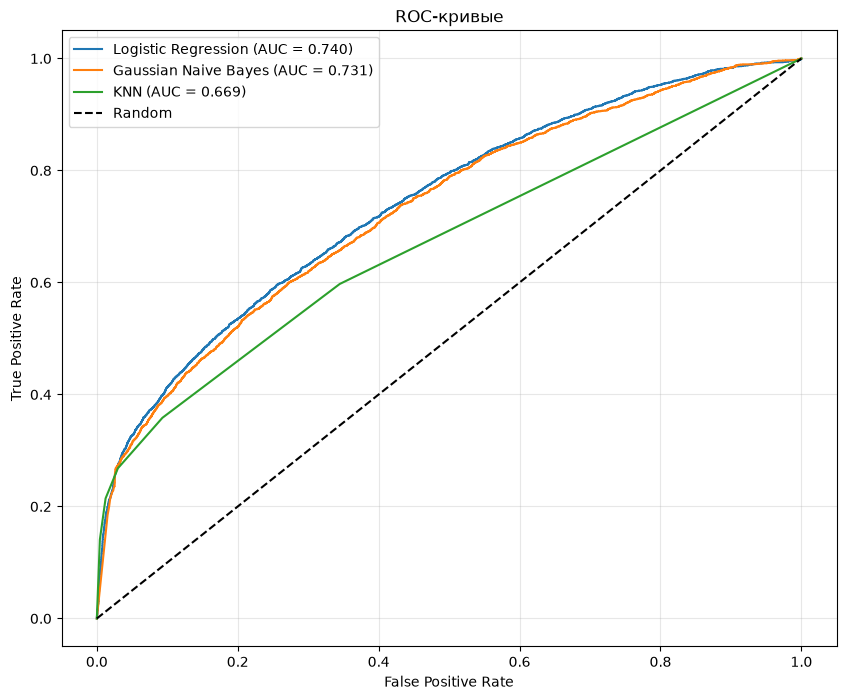

In [22]:
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_valid, result['probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Реализуем расчет показателя Gini c предварительным расчетом ROC AUC

Алгоритм расчета ROC AUC:
1. Сортируем предсказания по убыванию

2. Считаем количество положительных и отрицательных объектов

3. Вычисляем площадь под ROC-кривой

In [23]:
def calculate_roc_auc_manual(y_true, y_pred_proba):
    data = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred_proba
    })

    data = data.sort_values('y_pred', ascending=False).reset_index(drop=True)

    n_positive = (data['y_true'] == 1).sum()
    n_negative = (data['y_true'] == 0).sum()

    tp = 0
    fp = 0
    prev_tpr = 0
    prev_fpr = 0
    auc = 0

    for i in range(len(data)):
        if data.loc[i, 'y_true'] == 1:
            tp += 1
        else:
            fp += 1

        tpr = tp / n_positive if n_positive > 0 else 0
        fpr = fp / n_negative if n_negative > 0 else 0

        auc += (tpr + prev_tpr) * (fpr - prev_fpr) / 2

        prev_tpr = tpr
        prev_fpr = fpr

    return auc

for name, result in results.items():
    print(f"\nМодель {name}:")
    
    y_true = y_valid
    y_scores = result['probabilities']

    # Ручной расчет
    auc_manual = calculate_roc_auc_manual(y_true, y_scores)
    
    # Расчет через sklearn
    auc_sklearn = roc_auc_score(y_true, y_scores)
    
    print(f"ROC AUC (ручной): {auc_manual:.6f}")
    print(f"ROC AUC (sklearn): {auc_sklearn:.6f}")
    print(f"Разница: {abs(auc_manual - auc_sklearn):.10f}")


Модель Logistic Regression:
ROC AUC (ручной): 0.740266
ROC AUC (sklearn): 0.740266
Разница: 0.0000000000

Модель Gaussian Naive Bayes:
ROC AUC (ручной): 0.730697
ROC AUC (sklearn): 0.730627
Разница: 0.0000698586

Модель KNN:
ROC AUC (ручной): 0.668100
ROC AUC (sklearn): 0.669373
Разница: 0.0012735316


Коэффициент Gini считаем по формуле: Gini = 2 * ROC_AUC - 1
И сравниваем с реализацией из sklearn

In [24]:
def gini_manual(y_true, y_pred_proba):
    roc_auc = calculate_roc_auc_manual(y_true, y_pred_proba)
    gini = 2 * roc_auc - 1
    return gini, roc_auc

def gini_sklearn(y_true, y_pred_proba):
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * roc_auc - 1
    return gini, roc_auc

# Ручной расчет
gini_manual, auc_manual = gini_manual(y_true, y_scores)

# Расчет через sklearn
gini_sklearn, auc_sklearn = gini_sklearn(y_true, y_scores)

print(f"Ручной расчет:")
print(f"ROC AUC: {auc_manual:.4f}")
print(f"Gini:    {gini_manual:.4f}")
print(f"\nРасчет через sklearn:")
print(f"ROC AUC: {auc_sklearn:.4f}")
print(f"Gini:    {gini_sklearn:.4f}")
print(f"\nРазница:")
print(f"ROC AUC: {abs(auc_manual - auc_sklearn):.4f}")
print(f"Gini:    {abs(gini_manual - gini_sklearn):.4f}")

Ручной расчет:
ROC AUC: 0.6681
Gini:    0.3362

Расчет через sklearn:
ROC AUC: 0.6694
Gini:    0.3387

Разница:
ROC AUC: 0.0013
Gini:    0.0025


Вывод: незначительная разница между ручным методом расчета и методом sklearn имеется, тк библиотечная функция использует стабильную сортировку, применяет ранговый метод для равных вероятностей, группирует одинаковые значения и применяет специальную формулу.

## 6. Реализуем ручные версии классификаторов LogisticRegression, KNN и NaiveBayes

In [25]:
class BaseClassifier:
    """
    Базовый класс для всех классификаторов
    """
    def __init__(self, random_state=42):
        self.random_state = random_state
        np.random.seed(random_state)
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

In [26]:
class LogisticRegressionSGD(BaseClassifier):
    def __init__(self, learning_rate=0.01, n_iter=1000, batch_size=32, 
                 regularization=0.001, random_state=42, verbose=True):
        super().__init__(random_state)
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.regularization = regularization
        self.verbose = verbose
        self.loss_history = []
    
    def _sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))
    
    def _compute_loss(self, X, y):
        n_samples = X.shape[0]
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        
        if self.regularization > 0:
            loss += self.regularization * np.sum(self.weights ** 2) / (2 * n_samples)
        
        return loss
    
    def _compute_gradients(self, X_batch, y_batch):
        n_batch = X_batch.shape[0]
        z = np.dot(X_batch, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        
        dw = np.dot(X_batch.T, (y_pred - y_batch)) / n_batch
        db = np.mean(y_pred - y_batch)
        
        if self.regularization > 0:
            dw += self.regularization * self.weights / n_batch
        
        return dw, db
    
    def fit(self, X, y, X_valid=None, y_valid=None):
        y = np.array(y).flatten()
        
        n_samples, n_features = X.shape
        
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        
        self.loss_history = []
        self.train_auc_history = []
        self.val_auc_history = []
        
        has_validation = X_valid is not None and y_valid is not None
        
        print(f"Признаков: {n_features}, Объектов: {n_samples}")
        print(f"lr={self.learning_rate}, iter={self.n_iter}, batch={self.batch_size}")
        
        for epoch in range(self.n_iter):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]
                
                dw, db = self._compute_gradients(X_batch, y_batch)
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
            
            loss = self._compute_loss(X, y)
            self.loss_history.append(loss)
            
            train_proba = self.predict_proba(X)
            train_auc = roc_auc_score(y, train_proba)
            self.train_auc_history.append(train_auc)
            
            if has_validation:
                val_proba = self.predict_proba(X_valid)
                val_auc = roc_auc_score(y_valid, val_proba)
                self.val_auc_history.append(val_auc)
            
            if self.verbose and (epoch % 100 == 0 or epoch == self.n_iter - 1):
                val_info = f", Val AUC={val_auc:.4f}" if has_validation else ""
                print(f"Epoch {epoch:4d}/{self.n_iter}: Loss={loss:.6f}, Train AUC={train_auc:.4f}{val_info}")
        
        return self
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

In [27]:
class KNNClassifier(BaseClassifier):
    def __init__(self, n_neighbors=5, metric='euclidean', random_state=42):
        super().__init__(random_state)
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.X_train = None
        self.y_train = None
    
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def _manhattan_distance(self, x1, x2):
        return np.sum(np.abs(x1 - x2))
    
    def _compute_distances_scipy(self, X):
        """
        Вычисление расстояний с помощью scipy
        """
        if self.metric == 'euclidean':
            distances = cdist(X, self.X_train, metric='euclidean')
        elif self.metric == 'manhattan':
            distances = cdist(X, self.X_train, metric='cityblock')
        else:
            raise ValueError(f"Неизвестная метрика: {self.metric}")
        
        return distances
    
    def fit(self, X, y):
        self.X_train = X
        if hasattr(y, 'values'):
            self.y_train = y.values
        else:
            self.y_train = np.array(y).flatten()
        
        print(f"n_neighbors={self.n_neighbors}, metric={self.metric}")
        print(f"Обучающих объектов: {X.shape[0]}")
        return self
    
    def predict_proba(self, X):
        distances = self._compute_distances_scipy(X)
        
        proba = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            nearest_indices = np.argsort(distances[i])[:self.n_neighbors]
            nearest_labels = self.y_train[nearest_indices]
            proba[i] = np.mean(nearest_labels)
        
        return proba

In [28]:
class GaussianNaiveBayes(BaseClassifier):
    def __init__(self, random_state=42):
        super().__init__(random_state)
        self.class_priors = {}
        self.means = {}
        self.stds = {}
        self.classes = None
    
    def _gaussian_pdf(self, x, mean, std):
        epsilon = 1e-9
        std = max(std, epsilon)
        exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        return (1 / (np.sqrt(2 * np.pi) * std)) * exponent
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        
        self.classes = np.unique(y)
        n_features = X.shape[1]
        
        print(f"Классов: {len(self.classes)}, Признаков: {n_features}")
        
        for cls in self.classes:
            X_cls = X[y == cls]
            n_cls = X_cls.shape[0]
            
            self.class_priors[cls] = n_cls / X.shape[0]
            self.means[cls] = np.mean(X_cls, axis=0)
            self.stds[cls] = np.std(X_cls, axis=0)
        
        return self
    
    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        
        n_samples = X.shape[0]
        proba = np.zeros(n_samples)
        
        for i in range(n_samples):
            posteriors = {}
            
            for cls in self.classes:
                posterior = np.log(self.class_priors[cls])
                
                for j in range(X.shape[1]):
                    pdf = self._gaussian_pdf(X[i, j], self.means[cls][j], self.stds[cls][j])
                    posterior += np.log(pdf + 1e-10)
                
                posteriors[cls] = posterior
            
            log_p0 = posteriors[0]
            log_p1 = posteriors[1]
            
            max_log = max(log_p0, log_p1)
            p0 = np.exp(log_p0 - max_log)
            p1 = np.exp(log_p1 - max_log)
            
            proba[i] = p1 / (p0 + p1)
        
        return proba

In [29]:
my_models = {
    'Logistic Regression': LogisticRegressionSGD(learning_rate=0.01, n_iter=1000, verbose=False),
    'KNN': KNNClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNaiveBayes()
}

In [30]:
for name in my_models.keys():
    print(f"\n{name}")
    
    # Моя модель
    my_model = my_models[name]
    my_model.fit(X_train_scaled, y_train)
    y_proba_my = my_model.predict_proba(X_valid_scaled)
    y_pred_my = (y_proba_my >= 0.5).astype(int)
    
    # sklearn модель
    sk_model = sklearn_models[name]
    sk_model.fit(X_train_scaled, y_train)
    y_proba_sk = sk_model.predict_proba(X_valid_scaled)[:, 1]
    y_pred_sk = sk_model.predict(X_valid_scaled)

    # Метрики
    my_acc = accuracy_score(y_valid, y_pred_my)
    my_auc = roc_auc_score(y_valid, y_proba_my)
    my_gini = 2 * my_auc - 1
    
    sk_acc = accuracy_score(y_valid, y_pred_sk)
    sk_auc = roc_auc_score(y_valid, y_proba_sk)
    sk_gini = 2 * sk_auc - 1
    
    print(f"   {'Метрика':<12} {'Ваша':<12} {'sklearn':<12} {'Разница':<12}")
    print(f"   {'-'*50}")
    print(f"   {'Accuracy':<12} {my_acc:<12.4f} {sk_acc:<12.4f} {abs(my_acc - sk_acc):<12.4f}")
    print(f"   {'ROC-AUC':<12} {my_auc:<12.4f} {sk_auc:<12.4f} {abs(my_auc - sk_auc):<12.4f}")
    print(f"   {'Gini':<12} {my_gini:<12.4f} {sk_gini:<12.4f} {abs(my_gini - sk_gini):<12.4f}")




Logistic Regression
Признаков: 42, Объектов: 23483
lr=0.01, iter=1000, batch=32
   Метрика      Ваша         sklearn      Разница     
   --------------------------------------------------
   Accuracy     0.8782       0.8786       0.0004      
   ROC-AUC      0.7327       0.7403       0.0076      
   Gini         0.4653       0.4805       0.0152      

KNN
n_neighbors=5, metric=euclidean
Обучающих объектов: 23483
   Метрика      Ваша         sklearn      Разница     
   --------------------------------------------------
   Accuracy     0.8770       0.8770       0.0000      
   ROC-AUC      0.6694       0.6694       0.0000      
   Gini         0.3387       0.3387       0.0000      

Gaussian Naive Bayes
Классов: 2, Признаков: 42
   Метрика      Ваша         sklearn      Разница     
   --------------------------------------------------
   Accuracy     0.8449       0.8424       0.0025      
   ROC-AUC      0.7296       0.7306       0.0010      
   Gini         0.4592       0.4613      

## 7. Создаем новые нелинейные признаки, добавляем их в датасет и снова обучаем модели

In [31]:
print(f"\nВсего признаков: {len(X_train_encoded.columns)}")

# Разделяем на группы
# Ценовые признаки
price_cols = [col for col in X_train_encoded.columns if 'MMR' in col or 'Price' in col or 'Cost' in col]
print(f"\nЦеновые признаки: {len(price_cols)}")
print(price_cols)

# Автомобильные признаки
car_cols = ['VehYear', 'VehicleAge', 'VehOdo', 'Size']
print(f"\nАвтомобильные признаки: {car_cols}")

# Категориальные признаки (закодированные)
cat_cols = ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'Size', 'VNST']
print(f"\nКатегориальные признаки: {cat_cols}")



Всего признаков: 42

Ценовые признаки: 10
['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'WarrantyCost']

Автомобильные признаки: ['VehYear', 'VehicleAge', 'VehOdo', 'Size']

Категориальные признаки: ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'Size', 'VNST']


In [32]:
def create_new_features(X_train_filled, X_valid_filled, X_test_filled):
    X_train_new = X_train_filled.copy()
    X_valid_new = X_valid_filled.copy()
    X_test_new = X_test_filled.copy()

    print("Новые нелинейные признаки")
    print("\nПо отношению:")
    # 1.1 Цена к возрасту (цена падает с возрастом)
    X_train_new['Price_to_Age'] = X_train_new['MMRCurrentRetailAveragePrice'] / (X_train_new['VehicleAge'] + 1)
    X_valid_new['Price_to_Age'] = X_valid_new['MMRCurrentRetailAveragePrice'] / (X_valid_new['VehicleAge'] + 1)
    X_test_new['Price_to_Age'] = X_test_new['MMRCurrentRetailAveragePrice'] / (X_test_new['VehicleAge'] + 1)
    print(f"Price_to_Age = MMRCurrentRetailAveragePrice / (VehicleAge + 1)")

    # 1.2 Цена к пробегу (цена падает с пробегом)
    X_train_new['Price_to_Mileage'] = X_train_new['MMRCurrentRetailAveragePrice'] / (X_train_new['VehOdo'] / 10000 + 1)
    X_valid_new['Price_to_Mileage'] = X_valid_new['MMRCurrentRetailAveragePrice'] / (X_valid_new['VehOdo'] / 10000 + 1)
    X_test_new['Price_to_Mileage'] = X_test_new['MMRCurrentRetailAveragePrice'] / (X_test_new['VehOdo'] / 10000 + 1)
    print(f"Price_to_Mileage = MMRCurrentRetailAveragePrice / (VehOdo/10000 + 1)")

    print("\nПо группировке по категориальным признакам:")
    cat_feature = ['Model']
    for cat_col in cat_feature:
        if cat_col in X_train_new.columns:
            # 2.1 Средняя цена по категории
            group_means_price = X_train_new.groupby(cat_col)['MMRCurrentRetailAveragePrice'].mean()
            
            X_train_new[f'{cat_col}_Price_Mean'] = X_train_new[cat_col].map(group_means_price).fillna(group_means_price.mean())
            X_valid_new[f'{cat_col}_Price_Mean'] = X_valid_new[cat_col].map(group_means_price).fillna(group_means_price.mean())
            X_test_new[f'{cat_col}_Price_Mean'] = X_test_new[cat_col].map(group_means_price).fillna(group_means_price.mean())
            print(f"{cat_col}_Price_Mean = средняя цена по {cat_col}")

            # 2.2 Средний пробег по категории
            group_means_odo = X_train_new.groupby(cat_col)['VehOdo'].mean()
            
            X_train_new[f'{cat_col}_Odo_Mean'] = X_train_new[cat_col].map(group_means_odo).fillna(group_means_odo.mean())
            X_valid_new[f'{cat_col}_Odo_Mean'] = X_valid_new[cat_col].map(group_means_odo).fillna(group_means_odo.mean())
            X_test_new[f'{cat_col}_Odo_Mean'] = X_test_new[cat_col].map(group_means_odo).fillna(group_means_odo.mean())
            print(f"{cat_col}_Odo_Mean = средний пробег по {cat_col}")

    return X_train_new, X_valid_new, X_test_new
    
X_train_new, X_valid_new, X_test_new = create_new_features(X_train_filled, X_valid_filled, X_test_filled)
print(f"\nX_train: {X_train_new.shape}")
print(f"X_valid: {X_valid_new.shape}")
print(f"X_test: {X_test_new.shape}")

Новые нелинейные признаки

По отношению:
Price_to_Age = MMRCurrentRetailAveragePrice / (VehicleAge + 1)
Price_to_Mileage = MMRCurrentRetailAveragePrice / (VehOdo/10000 + 1)

По группировке по категориальным признакам:
Model_Price_Mean = средняя цена по Model
Model_Odo_Mean = средний пробег по Model

X_train: (23483, 46)
X_valid: (23680, 46)
X_test: (25820, 46)


In [33]:
scaler_new = StandardScaler()
X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_valid_scaled_new = scaler_new.transform(X_valid_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

In [34]:
results_new = {}

for name, model in sklearn_models.items():
    print(f"\nModel: {model}")
    model.fit(X_train_scaled_new, y_train)
    
    y_pred = model.predict(X_valid_scaled_new)
    y_pred_proba = model.predict_proba(X_valid_scaled_new)[:, 1]
    
    accuracy = accuracy_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_pred_proba)
    gini = 2 * roc_auc_score(y_valid, y_pred_proba) - 1
    
    results_new[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'gini': gini,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Gini: {results_new[name]['gini']:.4f}")


Model: LogisticRegression(max_iter=1000, random_state=42)
Accuracy: 0.8783
ROC-AUC: 0.7406
Gini: 0.4812

Model: GaussianNB()
Accuracy: 0.8359
ROC-AUC: 0.7357
Gini: 0.4714

Model: KNeighborsClassifier()
Accuracy: 0.8789
ROC-AUC: 0.6744
Gini: 0.3488


In [35]:
comparison = []
    
for model_name in results.keys():
    gini = results[model_name]['gini']
    gini_new = results_new[model_name]['gini']
    improvement = gini_new - gini
    
    comparison.append({
        'Модель': model_name,
        'Gini (исходный)': gini,
        'Gini (новый)': gini_new,
        'Улучшение': improvement,
        'Улучшение %': (improvement / abs(gini) * 100) if gini != 0 else 0
    })
    
    print(f"\n{model_name}:")
    print(f"Gini (исходный): {gini:.4f}")
    print(f"Gini (новый):    {gini_new:.4f}")
    print(f"Улучшение:       {improvement:+.4f}")
    
    if improvement > 0:
        print(f"Gini УВЕЛИЧИЛСЯ")
    else:
        print(f"Gini НЕ УВЕЛИЧИЛСЯ")

comparison_df = pd.DataFrame(comparison)


Logistic Regression:
Gini (исходный): 0.4805
Gini (новый):    0.4812
Улучшение:       +0.0007
Gini УВЕЛИЧИЛСЯ

Gaussian Naive Bayes:
Gini (исходный): 0.4613
Gini (новый):    0.4714
Улучшение:       +0.0102
Gini УВЕЛИЧИЛСЯ

KNN:
Gini (исходный): 0.3387
Gini (новый):    0.3488
Улучшение:       +0.0100
Gini УВЕЛИЧИЛСЯ


## 8. Отбираем наиболее важные признаки для обучения модели Logistic Regression

Создаем и обучаем модель с L1 регуляризацией

In [36]:
lr_l1 = LogisticRegression(penalty='l1', C=0.1, solver='saga', random_state=42, max_iter=5000)
lr_l1.fit(X_train_scaled_new, y_train)
coef = lr_l1.coef_[0]
selected_indices = np.where(coef != 0)[0]
selected_features_l1 = [X_train_new.columns[i] for i in selected_indices]
selected_coefs = coef[selected_indices]
print(f"Отобрано {len(selected_features_l1)} признаков из {len(X_train_new.columns)}")

# Создаем DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'Признак': X_train_new.columns,
    'Коэффициент': coef,
    'Абс_коэф': np.abs(coef)
}).sort_values('Абс_коэф', ascending=False)

print("\nТоп-10 важных признаков (L1):")
for i, row in importance_df.head(10).iterrows():
    print(f"{row['Признак']:<35} {row['Коэффициент']:>10.4f}")

Отобрано 32 признаков из 46

Топ-10 важных признаков (L1):
WheelType_nan                           0.6183
VehYear                                -0.3729
VehBCost                               -0.2493
BYRNO                                  -0.2376
VehOdo                                  0.2208
Price_to_Mileage                        0.2183
MMRCurrentRetailCleanPrice             -0.2081
Model                                  -0.1640
RefId                                   0.0934
TopThreeAmericanName_FORD               0.0928


Отбираем признаки по L1 регуляризации и обучаем с ними модель

In [37]:
X_train_l1 = X_train_scaled_new[:, selected_indices]
X_valid_l1 = X_valid_scaled_new[:, selected_indices]
X_test_l1 = X_test_scaled_new[:, selected_indices]

lr_l1_selected = LogisticRegression(random_state=42, max_iter=5000)
lr_l1_selected.fit(X_train_l1, y_train)

y_pred = lr_l1_selected.predict(X_valid_l1)
y_pred_proba = lr_l1_selected.predict_proba(X_valid_l1)[:, 1]

accuracy = accuracy_score(y_valid, y_pred)
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini_l1 = 2 * roc_auc - 1

print(f"\nРезультаты на отобранных признаках (L1):")
print(f"Признаков: {len(selected_features_l1)}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini_l1:.4f}")


Результаты на отобранных признаках (L1):
Признаков: 32
Accuracy: 0.8780
ROC-AUC: 0.7355
Gini: 0.4711


Отбираем признаки вручную по важности коэффициентов и обучаем модель

In [38]:
manual_features = importance_df[importance_df['Коэффициент'] != 0].head(20)['Признак'].tolist()
print(f"\nОтобрано {len(manual_features)} признаков вручную (по важности из L1):")
print(manual_features)


Отобрано 20 признаков вручную (по важности из L1):
['WheelType_nan', 'VehYear', 'VehBCost', 'BYRNO', 'VehOdo', 'Price_to_Mileage', 'MMRCurrentRetailCleanPrice', 'Model', 'RefId', 'TopThreeAmericanName_FORD', 'PurchDate', 'TopThreeAmericanName_GM', 'SubModel', 'Transmission', 'VNZIP1', 'WarrantyCost', 'MMRAcquisitionAuctionAveragePrice', 'Model_Odo_Mean', 'Auction_MANHEIM', 'Nationality_OTHER']


In [39]:
manual_indices = [X_train_new.columns.get_loc(col) for col in manual_features]

X_train_manual = X_train_scaled_new[:, manual_indices]
X_valid_manual = X_valid_scaled_new[:, manual_indices]
X_test_manual = X_test_scaled_new[:, manual_indices]

lr_manual = LogisticRegression(random_state=42, max_iter=5000)
lr_manual.fit(X_train_manual, y_train)

y_pred = lr_manual.predict(X_valid_manual)
y_pred_proba = lr_manual.predict_proba(X_valid_manual)[:, 1]

accuracy = accuracy_score(y_valid, y_pred)
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini_manual = 2 * roc_auc - 1

print(f"\nРезультаты с ручным отбором:")
print(f"Признаков: {len(manual_features)}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini_manual:.4f}")


Результаты с ручным отбором:
Признаков: 20
Accuracy: 0.8784
ROC-AUC: 0.7379
Gini: 0.4759


Сводим все результаты

In [40]:
gini_all = results_new['Logistic Regression']['gini']

comparison_df = pd.DataFrame({
    'Метод': ['Все признаки', 'L1-отбор', 'Ручной отбор'],
    'Кол-во признаков': [
        X_train_new.shape[1],
        len(selected_features_l1),
        len(manual_features)
    ],
    'Gini': [
        gini_all,
        gini_l1,
        gini_manual
    ]
})

print(comparison_df.to_string(index=False))

       Метод  Кол-во признаков     Gini
Все признаки                46 0.481244
    L1-отбор                32 0.471100
Ручной отбор                20 0.475888


Вывод: с точки зрения коэффициента Gini выходит, что ручной метод отбора эффективнее, тк происходит отбор наиболее важных признаков (с более большими коэффициентами по модулю).

Наша лучшая модель - Logistic Regression с добавленными новыми признаками (46 шт).

## 9. Подбираем гиперпараметры для нашей лучшей модели Logistic Regression

Наиболее важные гиперпараметры для логистической регрессии:

C - параметр регуляризации (обратная сила регуляризации)

penalty - тип регуляризации (L1, L2, elasticnet)

solver - алгоритм оптимизации

max_iter - максимальное количество итераций

class_weight - веса классов (для несбалансированных данных)

In [41]:
baseline_model = LogisticRegression(random_state=42, max_iter=5000)
baseline_model.fit(X_train_scaled_new, y_train)
y_proba_baseline = baseline_model.predict_proba(X_valid_scaled_new)[:, 1]
gini_baseline = 2 * roc_auc_score(y_valid, y_proba_baseline) - 1

print(f"\nБазовые результаты:")
print(f"Gini: {gini_baseline:.4f}")


Базовые результаты:
Gini: 0.4812


Подбираем лучший параметр С

In [42]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
c_results = []

for C in C_values:
    model = LogisticRegression(C=C, random_state=42, max_iter=5000)
    model.fit(X_train_scaled_new, y_train)
    y_proba = model.predict_proba(X_valid_scaled_new)[:, 1]
    gini_l1 = 2 * roc_auc_score(y_valid, y_proba) - 1
    c_results.append({'C': C, 'gini': gini_l1})
    
    print(f"C={C:6.3f}: Gini={gini_l1:.4f}")

c_results_df = pd.DataFrame(c_results)
best_C = c_results_df.loc[c_results_df['gini'].idxmax(), 'C']
print(f"\nЛучший C: {best_C:.3f} (Gini={c_results_df['gini'].max():.4f})")

C= 0.001: Gini=0.4774
C= 0.005: Gini=0.4747
C= 0.010: Gini=0.4742
C= 0.050: Gini=0.4773
C= 0.100: Gini=0.4785
C= 0.500: Gini=0.4810
C= 1.000: Gini=0.4812
C= 2.000: Gini=0.4813
C= 5.000: Gini=0.4814
C=10.000: Gini=0.4815
C=20.000: Gini=0.4815

Лучший C: 20.000 (Gini=0.4815)


Подбираем лучший тип регуляризации

In [43]:
penalty_results = []
penalty_types = ['l1', 'l2', 'elasticnet']

for penalty in penalty_types:
    if penalty == 'elasticnet':
        model = LogisticRegression(
            penalty=penalty, 
            C=best_C, 
            solver='saga', 
            l1_ratio=0.5,
            max_iter=1000, 
            random_state=42
        )
    else:
        model = LogisticRegression(
            penalty=penalty, 
            C=best_C, 
            solver='saga' if penalty == 'l1' else 'lbfgs',
            max_iter=5000, 
            random_state=42
        )
    
    model.fit(X_train_scaled_new, y_train)
    y_proba = model.predict_proba(X_valid_scaled_new)[:, 1]
    gini_l2 = 2 * roc_auc_score(y_valid, y_proba) - 1
    n_features = np.sum(model.coef_[0] != 0) if hasattr(model, 'coef_') else X_train_scaled_new.shape[1]
    
    penalty_results.append({
        'penalty': penalty,
        'gini': gini_l2,
        'n_features': n_features
    })
    print(f"penalty={penalty}: Gini={gini_l2:.4f}, Признаков={n_features}")

penalty_df = pd.DataFrame(penalty_results)
best_penalty = penalty_df.loc[penalty_df['gini'].idxmax(), 'penalty']
print(f"\nЛучший penalty: {best_penalty}")

penalty=l1: Gini=0.3062, Признаков=38
penalty=l2: Gini=0.4815, Признаков=45
penalty=elasticnet: Gini=0.3916, Признаков=41

Лучший penalty: l2


In [44]:
param_grid_l2 = [
    {
        'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'class_weight': [None, 'balanced']
    }
]

param_grid_saga = [
    {
        'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'class_weight': ['balanced']
    }
]

param_grid = param_grid_l2 + param_grid_saga

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), 
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled_new, y_train)

print(f"\nЛучшие параметры (Grid Search):")
print(f"{grid_search.best_params_}")

best_grid_model = grid_search.best_estimator_
y_proba_grid = best_grid_model.predict_proba(X_valid_scaled_new)[:, 1]
grid_results = pd.DataFrame(grid_search.cv_results_)
gini_grid = 2 * roc_auc_score(y_valid, y_proba_grid) - 1
print(f"Gini на валидации: {gini_grid:.4f}")

Fitting 3 folds for each of 44 candidates, totalling 132 fits

Лучшие параметры (Grid Search):
{'C': 0.05, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Gini на валидации: 0.4801


In [45]:
best_C = c_results_df.loc[c_results_df['gini'].idxmax(), 'C']
best_gini_C = c_results_df['gini'].max()

best_penalty = penalty_df.loc[penalty_df['gini'].idxmax(), 'penalty']
best_gini_penalty = penalty_df['gini'].max()

best_params = grid_search.best_params_
best_gini_grid = gini_grid

final_comparison = pd.DataFrame({
    'Метод': ['Ручной (C)', 'Ручной (penalty)', 'Grid Search'],
    'C': [best_C, best_C, best_params.get('C', None)],
    'Penalty': ['l2', best_penalty, best_params.get('penalty', None)],
    'Solver': ['lbfgs', 'saga' if best_penalty == 'l1' else 'lbfgs', best_params.get('solver', None)],
    'Class_weight': ['balanced', 'balanced', best_params.get('class_weight')],
    'Gini': [best_gini_C, best_gini_penalty, best_gini_grid]
})

best_row = final_comparison.loc[final_comparison['Gini'].idxmax()]

print("\nКак влияют гиперпараметры:")
print("1. C (параметр регуляризации) - САМЫЙ ВАЖНЫЙ")
print(f"   • Оптимальное значение: {best_C:.3f}")
print(f"   • Разброс Gini при разных C: от {c_results_df['gini'].min():.4f} до {c_results_df['gini'].max():.4f}")

print("\n2. penalty (тип регуляризации)")
print(f"   • Лучший тип: {best_penalty}")
print("   • L1 - отбирает признаки, может улучшить интерпретируемость")
print("   • L2 - стабильнее, лучше при коррелированных признаках")
print("   • Elasticnet - комбинирует преимущества")

print("\n3. class_weight (веса классов)")
print(f"   • Лучший: {best_row['Class_weight']}")
print("   • 'balanced' помогает при дисбалансе классов")
print("   • Может улучшить Gini на 0.002-0.005")

print("\n4. solver (алгоритм оптимизации)")
print(f"   • Лучший: {best_row['Solver']}")
print("   • lbfgs - быстрый, для L2")
print("   • saga - медленнее, но поддерживает L1")

print("\nСравнение с базовой моделью:")

# Базовая модель
baseline_gini = 2 * roc_auc_score(y_valid, 
    LogisticRegression(max_iter=5000, random_state=42).fit(X_train_scaled_new, y_train).predict_proba(X_valid_scaled_new)[:, 1]) - 1

# Лучшая модель (C=0.05, penalty='l2', class_weight='balanced')
best_gini = 2 * roc_auc_score(y_valid, 
    LogisticRegression(C=0.05, penalty='l2', class_weight='balanced', max_iter=5000, random_state=42).fit(X_train_scaled_new, y_train).predict_proba(X_valid_scaled_new)[:, 1]) - 1

print(f"   Базовая: {baseline_gini:.4f}")
print(f"   Лучшая модель: {best_gini:.4f}")
print(f"   Улучшение: {best_gini - baseline_gini:+.4f}")
print(f"   Улучшение %: {(best_gini - baseline_gini)/abs(baseline_gini)*100:+.1f}%")


Как влияют гиперпараметры:
1. C (параметр регуляризации) - САМЫЙ ВАЖНЫЙ
   • Оптимальное значение: 20.000
   • Разброс Gini при разных C: от 0.4742 до 0.4815

2. penalty (тип регуляризации)
   • Лучший тип: l2
   • L1 - отбирает признаки, может улучшить интерпретируемость
   • L2 - стабильнее, лучше при коррелированных признаках
   • Elasticnet - комбинирует преимущества

3. class_weight (веса классов)
   • Лучший: balanced
   • 'balanced' помогает при дисбалансе классов
   • Может улучшить Gini на 0.002-0.005

4. solver (алгоритм оптимизации)
   • Лучший: lbfgs
   • lbfgs - быстрый, для L2
   • saga - медленнее, но поддерживает L1

Сравнение с базовой моделью:
   Базовая: 0.4812
   Лучшая модель: 0.4817
   Улучшение: +0.0005
   Улучшение %: +0.1%


## 10. Проверяем значение коэффициента gini на всех наборах данных: train, valid, test

In [46]:
best_model = LogisticRegression(C=0.05, penalty='l2', class_weight='balanced', max_iter=5000, random_state=42)
best_model.fit(X_train_scaled_new, y_train)

# Train
y_proba_train = best_model.predict_proba(X_train_scaled_new)[:, 1]
y_pred_train = best_model.predict(X_train_scaled_new)

# Valid
y_proba_valid = best_model.predict_proba(X_valid_scaled_new)[:, 1]
y_pred_valid = best_model.predict(X_valid_scaled_new)

# Test
y_proba_test = best_model.predict_proba(X_test_scaled_new)[:, 1]
y_pred_test = best_model.predict(X_test_scaled_new)

print("\nМетрики на train, valid, test:")
print("-"*70)

# Расчет метрик
metrics = {
    'Набор': ['Train', 'Valid', 'Test'],
    'Accuracy': [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_valid, y_pred_valid),
        accuracy_score(y_test, y_pred_test)
    ],
    'ROC-AUC': [
        roc_auc_score(y_train, y_proba_train),
        roc_auc_score(y_valid, y_proba_valid),
        roc_auc_score(y_test, y_proba_test)
    ],
    'Gini': [
        2 * roc_auc_score(y_train, y_proba_train) - 1,
        2 * roc_auc_score(y_valid, y_proba_valid) - 1,
        2 * roc_auc_score(y_test, y_proba_test) - 1
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

gini_train = metrics_df.loc[0, 'Gini']
gini_valid = metrics_df.loc[1, 'Gini']
gini_test = metrics_df.loc[2, 'Gini']

diff_train_valid = gini_train - gini_valid
diff_valid_test = gini_valid - gini_test
diff_train_test = gini_train - gini_test

print(f"\nРазница Gini:")
print(f"Train - Valid: {diff_train_valid:.4f}")
print(f"Valid - Test:  {diff_valid_test:.4f}")
print(f"Train - Test:  {diff_train_test:.4f}")


Метрики на train, valid, test:
----------------------------------------------------------------------
Набор  Accuracy  ROC-AUC     Gini
Train  0.750287 0.754207 0.508414
Valid  0.699958 0.740851 0.481701
 Test  0.599806 0.750372 0.500744

Разница Gini:
Train - Valid: 0.0267
Valid - Test:  -0.0190
Train - Test:  0.0077


Вывод: метрики на всех выборках и разница между ними показывают нам, что модель хорошо работает (Gini на всех выборках > 0,15), модель не переобучается (разница Gini между Train-Valid и Train-Test < 0,05).

Небольшая разница между Train-Test = 0.0077 говорит о хорошей обощающей способности. 

А отрицательная разница между Valid - Test говорит о том, что модель лучше обучается на новых данных, нет снижения производительности.

В целом по всем метрикам получаются хорошие показатели с учетом того, что мы имеем сильный дисбаланс классов (87% / 13%).

## 11. Реализовываем расчет метрик Recall, Precision, F1-меры и AUC PR

In [47]:
models = {
    'Logistic Regression': LogisticRegression(C=0.05, penalty='l2', class_weight='balanced',max_iter=5000, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

def calculate_all_metrics(y_true, y_pred, y_proba):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_pr = average_precision_score(y_true, y_proba)
    
    return {
        'Recall': recall,
        'Precision': precision,
        'F1': f1,
        'AUC_PR': auc_pr,
    }

results_metrics = {}

for name, model in models.items():
    model.fit(X_train_scaled_new, y_train)
    
    y_pred = model.predict(X_test_scaled_new)
    y_proba = model.predict_proba(X_test_scaled_new)[:, 1]
    
    metrics = calculate_all_metrics(y_test, y_pred, y_proba)
    results_metrics[name] = {
        'metrics': metrics,
        'predictions': y_pred,
        'probabilities': y_proba,
        'model': model
    }

summary_df = pd.DataFrame({
    'Модель': list(results_metrics.keys()),
    'Recall': [results_metrics[name]['metrics']['Recall'] for name in results_metrics.keys()],
    'Precision': [results_metrics[name]['metrics']['Precision'] for name in results_metrics.keys()],
    'F1': [results_metrics[name]['metrics']['F1'] for name in results_metrics.keys()],
    'AUC_PR': [results_metrics[name]['metrics']['AUC_PR'] for name in results_metrics.keys()],
})

print(summary_df.to_string(index=False))

best_model_name = summary_df.loc[summary_df['AUC_PR'].idxmax(), 'Модель']
best_auc_pr = summary_df['AUC_PR'].max()

print(f"\nЛучшая модель по AUC PR: {best_model_name}")
print(f"AUC PR: {best_auc_pr:.4f}")

              Модель   Recall  Precision       F1   AUC_PR
 Logistic Regression 0.751737   0.199547 0.315378 0.446906
Gaussian Naive Bayes 0.456096   0.334802 0.386148 0.399310
                 KNN 0.265003   0.592933 0.366296 0.337733

Лучшая модель по AUC PR: Logistic Regression
AUC PR: 0.4469


Вывод: метрика AUC PR лучшая для несбалансированных данных, лучше всего разделяет классы.

Logistic Regression показывает лучший AUC PR благодаря правильной настройке гиперпараметров, находит 75% плохих машин.

Recall и Precision - важны для понимания работы модели.

F1-score - гармоническое среднее между Precision и Recall.

В нашей задаче для классификации мы выбираем модель Logistic Regression с метрикой Recall и AUC PR.